Generating new PSCs (perovskite composition and other layers, within given limits/material selection) - VAE model

FINAL VAE code with training loop:

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset

# === Step 1: Load & Preprocess Data ===
def load_data(csv_path, selected_columns):
    """Load dataset, select relevant columns, normalize and convert to tensor."""
    df = pd.read_csv(r'C:\Users\c\OneDrive\Documents\PEROVSKITE PROJECT\PerovskiteML_project\Regression model\cleaned_data_for_regression.csv')
    data = df[selected_columns].fillna(0).values  # Handle NaNs if any

    # Normalize data to be between 0 and 1 (Min-Max Scaling)
    data = data / np.max(data, axis=0, where=(np.max(data, axis=0) != 0), initial=1)

    return torch.tensor(data, dtype=torch.float32)

# === Step 2: Define VAE Model ===
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=5):
        super(VAE, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )
        self.mu_layer = nn.Linear(16, latent_dim)
        self.logvar_layer = nn.Linear(16, latent_dim)
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.mu_layer(h), self.logvar_layer(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# === Step 3: Define Loss Function (Reconstruction + KL Divergence) ===
def vae_loss_function(recon_x, x, mu, logvar):
    recon_loss = nn.MSELoss()(recon_x, x)  # Reconstruction loss
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())  # KL divergence
    return recon_loss + 0.001 * kl_div  # Scale KL term to avoid overpowering

# === Step 4: Train the VAE ===
def train_vae(model, dataloader, epochs=100, lr=0.0001):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    for epoch in range(epochs):
        total_loss = 0
        for batch in dataloader:
            x = batch[0]
            optimizer.zero_grad()
            recon_x, mu, logvar = model(x)
            loss = vae_loss_function(recon_x, x, mu, logvar)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss / len(dataloader):.4f}")
    
    print("Training complete.")
    return model

Rest of code with added randomness:

In [2]:
import torch
import numpy as np

# Define materials groups
selected_columns = ['SLG|ITO', 'SLG|FTO', 'TiO2-c', 'TiO2-c|TiO2-mp', 'MA', 'FA', 'Cs', 'Pb', 'Br', 'I', 
                    'Spiro-MeOTAD', 'PEDOT:PSS', 'Au', 'Ag']
non_perovskite_materials = ['SLG|ITO', 'SLG|FTO', 'TiO2-c', 'TiO2-c|TiO2-mp', 'Spiro-MeOTAD', 'PEDOT:PSS', 'Au', 'Ag']


def generate_samples(model, num_samples=1000, latent_std=1.0):
    model.eval()
    with torch.no_grad():
        z = torch.normal(0, latent_std, size=(num_samples, model.mu_layer.out_features))  # More variance in sampling
        generated = model.decode(z).numpy()  
    return enforce_perovskite_constraints(generated, selected_columns, non_perovskite_materials, randomness=True)

def enforce_perovskite_constraints(generated_vectors, selected_columns, non_perovskite_materials, randomness=False):
    corrected_vectors = []

    for vector in generated_vectors:
        corrected_vector = vector.copy()

        # Ensure Pb is always 1
        pb_idx = selected_columns.index('Pb')
        corrected_vector[pb_idx] = 1.0

        # Binary enforcement with small random jitter
        for material in non_perovskite_materials:
            idx = selected_columns.index(material)
            corrected_vector[idx] = 1.0 if corrected_vector[idx] > np.random.uniform(0.4, 0.6) else 0.0

        # Handle A-site cations (MA, FA, Cs)
        a_indices = [selected_columns.index(m) for m in ['MA', 'FA', 'Cs']]
        a_values = corrected_vector[a_indices]
        num_a = np.count_nonzero(a_values)

        if num_a == 0:
            corrected_vector[a_indices[np.random.randint(0, 3)]] = 1.0
        elif num_a == 3:
            corrected_vector[a_indices] = [min(corrected_vector[a_indices[0]], np.random.uniform(0.4, 0.6)),
                                           min(corrected_vector[a_indices[1]], np.random.uniform(0.5, 0.7)),
                                           min(corrected_vector[a_indices[2]], np.random.uniform(0.1, 0.2))]

        # Handle C-site anions (Br, I)
        c_indices = [selected_columns.index(m) for m in ['Br', 'I']]
        c_values = corrected_vector[c_indices]
        num_c = np.count_nonzero(c_values)

        if num_c == 0:
            corrected_vector[c_indices[np.random.randint(0, 2)]] = 1.0
        elif num_c == 2:
            corrected_vector[c_indices] = [min(corrected_vector[c_indices[0]], np.random.uniform(0.2, 0.4)), 
                                           max(corrected_vector[c_indices[1]], np.random.uniform(0.6, 0.8))]

        corrected_vectors.append(corrected_vector)

    return np.array(corrected_vectors)

def decode_generated_samples(generated_vectors, selected_columns, threshold=0.1):
    decoded_samples = []
    
    for vector in generated_vectors:
        decoded_stack = {}
        
        # Extract perovskite composition
        MA, FA, Cs = vector[selected_columns.index('MA')], vector[selected_columns.index('FA')], vector[selected_columns.index('Cs')]
        Pb = 1.0  # Pb must always be 1
        Br, I = vector[selected_columns.index('Br')], vector[selected_columns.index('I')]

        # Enforce A-site constraints
        a_ions = [MA, FA, Cs]
        num_a_ions = sum(val > threshold for val in a_ions)

        if num_a_ions == 0:
            MA = 1.0  # Default to MA
        elif num_a_ions == 2 and Cs > threshold:
            Cs = 0.0
            total = MA + FA
            MA /= total
            FA /= total
        elif num_a_ions == 3:
            MA, FA, Cs = min(MA, 0.5), min(FA, 0.5), min(Cs, 0.15)

        # Enforce C-site constraints
        num_c_ions = sum(val > threshold for val in [Br, I])
        if num_c_ions == 0:
            I = 1.0
        elif num_c_ions == 2:
            Br, I = min(Br, 0.3), max(I, 0.7)

        # Assign values
        decoded_stack.update({'MA': round(MA, 2), 'FA': round(FA, 2), 'Cs': round(Cs, 2), 
                              'Pb': Pb, 'Br': round(Br, 2), 'I': round(I, 2)})

        # Enforce binary constraints for non-perovskite materials
        for material in selected_columns:
            if material not in ['MA', 'FA', 'Cs', 'Pb', 'Br', 'I']:
                decoded_stack[material] = int(vector[selected_columns.index(material)] > threshold)

        decoded_samples.append(decoded_stack)
    
    return decoded_samples

def main():
    csv_path = r"C:\Users\c\OneDrive\Documents\PEROVSKITE PROJECT\PerovskiteML_project\Regression model\cleaned_data_for_regression.csv"

    # Load and preprocess data
    data = load_data(csv_path, selected_columns)
    dataset = TensorDataset(data)
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

    # Initialize model
    input_dim = len(selected_columns)
    vae = VAE(input_dim)

    # Train model
    trained_vae = train_vae(vae, dataloader, epochs=50, lr=0.001)

    # Generate and decode new samples
    new_samples = generate_samples(trained_vae, num_samples=1000, latent_std=1)
    decoded_samples = decode_generated_samples(new_samples, selected_columns)

    # Convert decoded samples to DataFrame and save to CSV
    df = pd.DataFrame(decoded_samples)
    output_csv_path = r"C:\Users\c\OneDrive\Documents\PEROVSKITE PROJECT\PEROVSKITEML_PROJECT\Composition model\generated_perovskite_stacks.csv"
    df.to_csv(output_csv_path, index=False)

    print(f"\nGenerated Perovskite Cell Stacks saved to {output_csv_path}")

    # Save model
    torch.save(trained_vae.state_dict(), "vae_model.pth")
    print("\nModel saved as 'vae_model.pth'.")

if __name__ == "__main__":
    main()

Epoch 1/50, Loss: 0.1144
Epoch 2/50, Loss: 0.0830
Epoch 3/50, Loss: 0.0773
Epoch 4/50, Loss: 0.0761
Epoch 5/50, Loss: 0.0748
Epoch 6/50, Loss: 0.0746
Epoch 7/50, Loss: 0.0741
Epoch 8/50, Loss: 0.0739
Epoch 9/50, Loss: 0.0737
Epoch 10/50, Loss: 0.0740
Epoch 11/50, Loss: 0.0737
Epoch 12/50, Loss: 0.0721
Epoch 13/50, Loss: 0.0710
Epoch 14/50, Loss: 0.0699
Epoch 15/50, Loss: 0.0691
Epoch 16/50, Loss: 0.0691
Epoch 17/50, Loss: 0.0690
Epoch 18/50, Loss: 0.0693
Epoch 19/50, Loss: 0.0687
Epoch 20/50, Loss: 0.0685
Epoch 21/50, Loss: 0.0689
Epoch 22/50, Loss: 0.0685
Epoch 23/50, Loss: 0.0689
Epoch 24/50, Loss: 0.0683
Epoch 25/50, Loss: 0.0680
Epoch 26/50, Loss: 0.0689
Epoch 27/50, Loss: 0.0685
Epoch 28/50, Loss: 0.0689
Epoch 29/50, Loss: 0.0691
Epoch 30/50, Loss: 0.0678
Epoch 31/50, Loss: 0.0687
Epoch 32/50, Loss: 0.0684
Epoch 33/50, Loss: 0.0685
Epoch 34/50, Loss: 0.0679
Epoch 35/50, Loss: 0.0694
Epoch 36/50, Loss: 0.0685
Epoch 37/50, Loss: 0.0685
Epoch 38/50, Loss: 0.0686
Epoch 39/50, Loss: 0.

Comparing experimental to generated stacks:

c:\Users\c\miniconda3\envs\test-env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


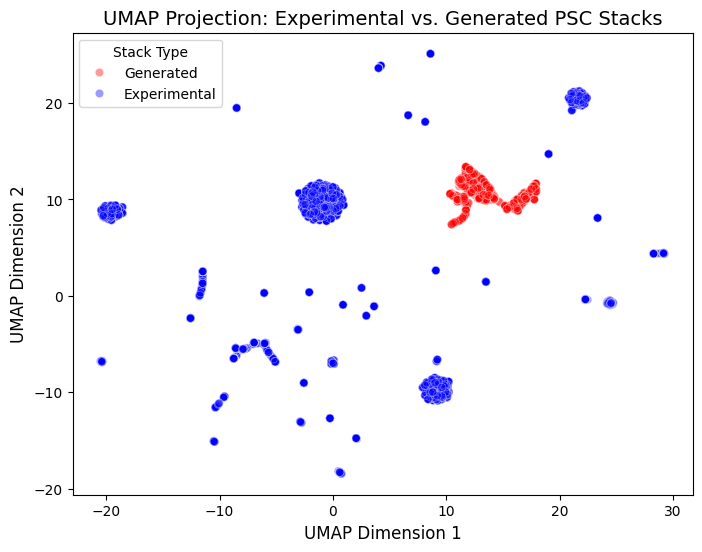

In [3]:
import numpy as np
import pandas as pd
import umap
import matplotlib.pyplot as plt
import seaborn as sns

# 🔹 Step 1: Load Data
generated_df = pd.read_csv("generated_perovskite_stacks.csv")
experimental_df = pd.read_csv(r'C:\Users\c\OneDrive\Documents\PEROVSKITE PROJECT\PerovskiteML_project\Regression model\cleaned_data_for_regression.csv')

# 🔹 Step 2: Restrict Experimental Data to Matching Columns
common_columns = list(set(generated_df.columns) & set(experimental_df.columns))
experimental_df = experimental_df[common_columns]

# 🔹 Step 3: Convert Data to NumPy Arrays
X_generated = generated_df.to_numpy()
X_experimental = experimental_df.to_numpy()

# 🔹 Step 4: Create Labels
labels_generated = ["Generated"] * len(X_generated)
labels_experimental = ["Experimental"] * len(X_experimental)

# 🔹 Step 5: Combine Both Datasets
X_all = np.vstack([X_generated, X_experimental])
labels_all = np.array(labels_generated + labels_experimental)

# 🔹 Step 6: Apply UMAP for Dimensionality Reduction
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)
X_umap = umap_model.fit_transform(X_all)

# 🔹 Step 7: Create DataFrame for Visualization
df_umap = pd.DataFrame(X_umap, columns=["UMAP_1", "UMAP_2"])
df_umap["Type"] = labels_all  # Label as Experimental or Generated

# 🔹 Step 8: Plot UMAP Visualization
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_umap, x="UMAP_1", y="UMAP_2", hue="Type", alpha=0.4, palette={"Experimental": "blue", "Generated": "red"})
plt.title("UMAP Projection: Experimental vs. Generated PSC Stacks", fontsize=14)
plt.xlabel("UMAP Dimension 1", fontsize=12)
plt.ylabel("UMAP Dimension 2", fontsize=12)
plt.legend(title="Stack Type")
plt.show()

FULL CVAE code for high PCE stacks:

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset

# === Step 1: Load & Preprocess Data ===
def load_data(csv_path, selected_columns, pce_column):
    """Load dataset, select relevant columns, normalize and convert to tensor."""
    df = pd.read_csv(r'C:\Users\c\OneDrive\Documents\PEROVSKITE PROJECT\PerovskiteML_project\Regression model\cleaned_data_for_regression.csv')
    data = df[selected_columns].fillna(0).values  # Handle NaNs

    # Normalize data (Min-Max Scaling)
    data = data / np.max(data, axis=0, where=(np.max(data, axis=0) != 0), initial=1)

    # Normalize PCE separately
    pce_values = df[pce_column].fillna(0).values
    pce_values = pce_values / np.max(pce_values)  # Scale between 0 and 1

    # Convert to tensor
    return torch.tensor(data, dtype=torch.float32), torch.tensor(pce_values, dtype=torch.float32).unsqueeze(1)


# === Step 2: Define Conditional VAE (CVAE) ===
class CVAE(nn.Module):
    def __init__(self, input_dim, latent_dim=5):
        super(CVAE, self).__init__()
        self.latent_dim = latent_dim

        # Encoder (input + PCE conditioning)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim + 1, 32),  # +1 for PCE input
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )
        self.mu_layer = nn.Linear(16, latent_dim)
        self.logvar_layer = nn.Linear(16, latent_dim)

        # Decoder (latent + PCE conditioning)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + 1, 16),  # +1 for PCE input
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim),
            nn.Sigmoid()
        )

    def encode(self, x, pce):
        h = self.encoder(torch.cat([x, pce], dim=1))
        return self.mu_layer(h), self.logvar_layer(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, pce):
        return self.decoder(torch.cat([z, pce], dim=1))

    def forward(self, x, pce):
        mu, logvar = self.encode(x, pce)
        z = self.reparameterize(mu, logvar)
        return self.decode(z, pce), mu, logvar

# === Step 3: Define Loss Function (Reconstruction + KL Divergence) ===
def cvae_loss_function(recon_x, x, mu, logvar):
    recon_loss = nn.MSELoss()(recon_x, x)  # Reconstruction loss
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())  # KL divergence
    return recon_loss + 0.001 * kl_div  # Scale KL term

# === Step 4: Train the CVAE ===
def train_cvae(model, dataloader, epochs=100, lr=0.0001):
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        total_loss = 0
        for batch in dataloader:
            x, pce = batch
            optimizer.zero_grad()
            recon_x, mu, logvar = model(x, pce)
            loss = cvae_loss_function(recon_x, x, mu, logvar)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss / len(dataloader):.4f}")

    print("Training complete.")
    return model

In [5]:
import torch
import numpy as np

# Define materials groups
selected_columns = ['SLG|ITO', 'SLG|FTO', 'TiO2-c', 'TiO2-c|TiO2-mp', 'MA', 'FA', 'Cs', 'Pb', 'Br', 'I', 
                    'Spiro-MeOTAD', 'PEDOT:PSS', 'Au', 'Ag']
non_perovskite_materials = ['SLG|ITO', 'SLG|FTO', 'TiO2-c', 'TiO2-c|TiO2-mp', 'Spiro-MeOTAD', 'PEDOT:PSS', 'Au', 'Ag']
pce_column = 'JV_default_PCE'

def generate_high_pce_samples(model, num_samples=1000, desired_pce=0.9, latent_std=1.0):
    """Generate perovskite compositions conditioned on high PCE values."""
    model.eval()
    with torch.no_grad():
        # Sample latent space
        z = torch.normal(0, latent_std, size=(num_samples, model.latent_dim))

        # Condition on high PCE (scaled between 0 and 1)
        pce_tensor = torch.full((num_samples, 1), desired_pce)

        # Generate new compositions
        generated = model.decode(z, pce_tensor).numpy()

    return enforce_perovskite_constraints(generated, selected_columns, non_perovskite_materials, randomness=True)

def enforce_perovskite_constraints(generated_vectors, selected_columns, non_perovskite_materials, randomness=False):
    corrected_vectors = []

    for vector in generated_vectors:
        corrected_vector = vector.copy()

        # Ensure Pb is always 1
        pb_idx = selected_columns.index('Pb')
        corrected_vector[pb_idx] = 1.0

        # Binary enforcement with small random jitter
        for material in non_perovskite_materials:
            idx = selected_columns.index(material)
            corrected_vector[idx] = 1.0 if corrected_vector[idx] > np.random.uniform(0.4, 0.6) else 0.0

        # Handle A-site cations (MA, FA, Cs)
        a_indices = [selected_columns.index(m) for m in ['MA', 'FA', 'Cs']]
        a_values = corrected_vector[a_indices]
        num_a = np.count_nonzero(a_values)

        if num_a == 0:
            corrected_vector[a_indices[np.random.randint(0, 3)]] = 1.0
        elif num_a == 3:
            corrected_vector[a_indices] = [min(corrected_vector[a_indices[0]], np.random.uniform(0.4, 0.6)),
                                           min(corrected_vector[a_indices[1]], np.random.uniform(0.5, 0.7)),
                                           min(corrected_vector[a_indices[2]], np.random.uniform(0.1, 0.2))]

        # Handle C-site anions (Br, I)
        c_indices = [selected_columns.index(m) for m in ['Br', 'I']]
        c_values = corrected_vector[c_indices]
        num_c = np.count_nonzero(c_values)

        if num_c == 0:
            corrected_vector[c_indices[np.random.randint(0, 2)]] = 1.0
        elif num_c == 2:
            corrected_vector[c_indices] = [min(corrected_vector[c_indices[0]], np.random.uniform(0.2, 0.4)), 
                                           max(corrected_vector[c_indices[1]], np.random.uniform(0.6, 0.8))]

        corrected_vectors.append(corrected_vector)

    return np.array(corrected_vectors)

def decode_generated_samples(generated_vectors, selected_columns, threshold=0.1):
    decoded_samples = []
    
    for vector in generated_vectors:
        decoded_stack = {}
        
        # Extract perovskite composition
        MA, FA, Cs = vector[selected_columns.index('MA')], vector[selected_columns.index('FA')], vector[selected_columns.index('Cs')]
        Pb = 1.0  # Pb must always be 1
        Br, I = vector[selected_columns.index('Br')], vector[selected_columns.index('I')]

        # Enforce A-site constraints
        a_ions = [MA, FA, Cs]
        num_a_ions = sum(val > threshold for val in a_ions)

        if num_a_ions == 0:
            MA = 1.0  # Default to MA
        elif num_a_ions == 2 and Cs > threshold:
            Cs = 0.0
            total = MA + FA
            MA /= total
            FA /= total
        elif num_a_ions == 3:
            MA, FA, Cs = min(MA, 0.5), min(FA, 0.5), min(Cs, 0.15)

        # Enforce C-site constraints
        num_c_ions = sum(val > threshold for val in [Br, I])
        if num_c_ions == 0:
            I = 1.0
        elif num_c_ions == 2:
            Br, I = min(Br, 0.3), max(I, 0.7)

        # Assign values
        decoded_stack.update({'MA': round(MA, 2), 'FA': round(FA, 2), 'Cs': round(Cs, 2), 
                              'Pb': Pb, 'Br': round(Br, 2), 'I': round(I, 2)})

        # Enforce binary constraints for non-perovskite materials
        for material in selected_columns:
            if material not in ['MA', 'FA', 'Cs', 'Pb', 'Br', 'I']:
                decoded_stack[material] = int(vector[selected_columns.index(material)] > threshold)

        decoded_samples.append(decoded_stack)
    
    return decoded_samples

def main():
    csv_path = r"C:\Users\c\OneDrive\Documents\PEROVSKITE PROJECT\PerovskiteML_project\Regression model\cleaned_data_for_regression.csv"
    pce_column = "JV_default_PCE"  # Ensure this column exists in your dataset

    # Load and preprocess data
    data, pce = load_data(csv_path, selected_columns, pce_column)
    dataset = TensorDataset(data, pce)
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

    # Initialize model
    input_dim = len(selected_columns)
    cvae = CVAE(input_dim)

    # Train model
    trained_cvae = train_cvae(cvae, dataloader, epochs=50, lr=0.001)

    # Generate and decode new high-PCE samples
    high_pce_samples = generate_high_pce_samples(trained_cvae, num_samples=1000, desired_pce=0.9)
    decoded_samples = decode_generated_samples(high_pce_samples, selected_columns)

    # Convert decoded samples to DataFrame and save to CSV
    df = pd.DataFrame(decoded_samples)
    output_csv_path = r"C:\Users\c\OneDrive\Documents\PEROVSKITE PROJECT\Generated_High_PCE_Samples.csv"
    df.to_csv(output_csv_path, index=False)

    print(f"Generated high-PCE samples saved to: {output_csv_path}")

if __name__ == "__main__":
    main()

Epoch 1/50, Loss: 0.1197
Epoch 2/50, Loss: 0.0831
Epoch 3/50, Loss: 0.0784
Epoch 4/50, Loss: 0.0760
Epoch 5/50, Loss: 0.0744
Epoch 6/50, Loss: 0.0740
Epoch 7/50, Loss: 0.0738
Epoch 8/50, Loss: 0.0743
Epoch 9/50, Loss: 0.0742
Epoch 10/50, Loss: 0.0737
Epoch 11/50, Loss: 0.0735
Epoch 12/50, Loss: 0.0738
Epoch 13/50, Loss: 0.0728
Epoch 14/50, Loss: 0.0713
Epoch 15/50, Loss: 0.0706
Epoch 16/50, Loss: 0.0703
Epoch 17/50, Loss: 0.0691
Epoch 18/50, Loss: 0.0688
Epoch 19/50, Loss: 0.0691
Epoch 20/50, Loss: 0.0694
Epoch 21/50, Loss: 0.0688
Epoch 22/50, Loss: 0.0690
Epoch 23/50, Loss: 0.0687
Epoch 24/50, Loss: 0.0688
Epoch 25/50, Loss: 0.0685
Epoch 26/50, Loss: 0.0680
Epoch 27/50, Loss: 0.0692
Epoch 28/50, Loss: 0.0685
Epoch 29/50, Loss: 0.0686
Epoch 30/50, Loss: 0.0683
Epoch 31/50, Loss: 0.0684
Epoch 32/50, Loss: 0.0684
Epoch 33/50, Loss: 0.0683
Epoch 34/50, Loss: 0.0681
Epoch 35/50, Loss: 0.0682
Epoch 36/50, Loss: 0.0681
Epoch 37/50, Loss: 0.0678
Epoch 38/50, Loss: 0.0684
Epoch 39/50, Loss: 0.

Compare high PCE generated stacks to experimental:

In [ ]:
import numpy as np
import pandas as pd
import umap
import matplotlib.pyplot as plt
import seaborn as sns

# 🔹 Step 1: Load Data
generated_df = pd.read_csv(r'C:\Users\c\OneDrive\Documents\PEROVSKITE PROJECT\Generated_High_PCE_Samples.csv')
experimental_df = pd.read_csv(r'C:\Users\c\OneDrive\Documents\PEROVSKITE PROJECT\PerovskiteML_project\Regression model\cleaned_data_for_regression.csv')

# 🔹 Step 2: Restrict Experimental Data to Matching Columns
common_columns = list(set(generated_df.columns) & set(experimental_df.columns))
experimental_df = experimental_df[common_columns]

# 🔹 Step 3: Convert Data to NumPy Arrays
X_generated = generated_df.to_numpy()
X_experimental = experimental_df.to_numpy()

# 🔹 Step 4: Create Labels
labels_generated = ["Generated"] * len(X_generated)
labels_experimental = ["Experimental"] * len(X_experimental)

# 🔹 Step 5: Combine Both Datasets
X_all = np.vstack([X_generated, X_experimental])
labels_all = np.array(labels_generated + labels_experimental)

# 🔹 Step 6: Apply UMAP for Dimensionality Reduction
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)
X_umap = umap_model.fit_transform(X_all)

# 🔹 Step 7: Create DataFrame for Visualization
df_umap = pd.DataFrame(X_umap, columns=["UMAP_1", "UMAP_2"])
df_umap["Type"] = labels_all  # Label as Experimental or Generated

# 🔹 Step 8: Plot UMAP Visualization
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_umap, x="UMAP_1", y="UMAP_2", hue="Type", alpha=0.4, palette={"Experimental": "blue", "Generated": "red"})
plt.title("UMAP Projection: Experimental vs. Generated PSC Stacks", fontsize=14)
plt.xlabel("UMAP Dimension 1", fontsize=12)
plt.ylabel("UMAP Dimension 2", fontsize=12)
plt.legend(title="Stack Type")
plt.show()

c:\Users\c\miniconda3\envs\test-env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Plot band gap vs PCE for 'high PCE' generated stacks:

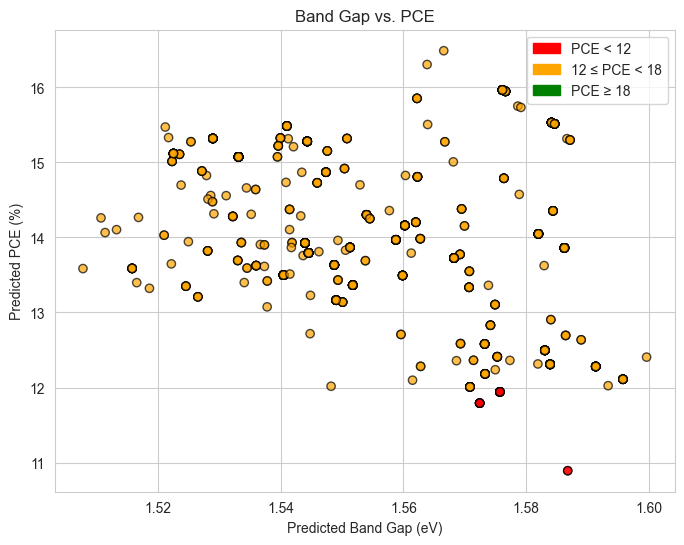

In [ ]:
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt
import pickle

# === Step 1: Load Dataset ===
csv_path = r'C:\Users\c\OneDrive\Documents\PEROVSKITE PROJECT\Generated_High_PCE_Samples.csv'
df = pd.read_csv(csv_path)

# Use all columns as features
X = df.copy()  

# === Step 2: Load Pretrained XGBoost Models (Pickle Format) ===
with open(r"C:\Users\c\OneDrive\Documents\PEROVSKITE PROJECT\PerovskiteML_project\Composition model\best_xgb_Perovskite_band_gap.1.pkl", "rb") as f:
    bandgap_model = pickle.load(f)

with open(r"C:\Users\c\OneDrive\Documents\PEROVSKITE PROJECT\PerovskiteML_project\Composition model\best_xgb_JV_default_PCE.pkl", "rb") as f:
    pce_model = pickle.load(f)

# === Step 3: Make Predictions ===
df["Predicted_Bandgap"] = bandgap_model.predict(X)
df["Predicted_PCE"] = pce_model.predict(X)

# === Step 4: Define Colors Based on PCE Ranges ===
colors = df["Predicted_PCE"].apply(lambda pce: 'red' if pce < 12 else ('orange' if pce < 18 else 'green'))

# === Step 5: Plot Bandgap vs. PCE with Colors ===
plt.figure(figsize=(8, 6))
plt.scatter(df["Predicted_Bandgap"], df["Predicted_PCE"], c=colors, alpha=0.7, edgecolors='k')
plt.xlabel("Predicted Band Gap (eV)")
plt.ylabel("Predicted PCE (%)")
plt.title("Band Gap vs. PCE")

# Add a legend
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color='red', label="PCE < 12"),
    mpatches.Patch(color='orange', label="12 ≤ PCE < 18"),
    mpatches.Patch(color='green', label="PCE ≥ 18"),
]
plt.legend(handles=legend_patches)

plt.grid(True)
plt.show()


     MA    FA    Cs   Pb    Br     I  SLG|ITO  SLG|FTO  TiO2-c  \
0  0.48  0.00  0.00  1.0  0.00  1.00        0        1       0   
1  0.17  0.52  0.02  1.0  0.19  0.81        0        1       0   
2  0.00  0.01  0.15  1.0  0.30  0.77        1        0       1   
3  0.57  0.00  0.00  1.0  0.04  0.97        0        1       0   
4  0.59  0.00  0.00  1.0  0.00  1.00        1        0       1   

   TiO2-c|TiO2-mp  Spiro-MeOTAD  PEDOT:PSS  Au  Ag  
0               1             1          0   1   0  
1               1             1          0   1   0  
2               0             1          0   0   1  
3               1             1          0   1   0  
4               0             1          0   0   1  


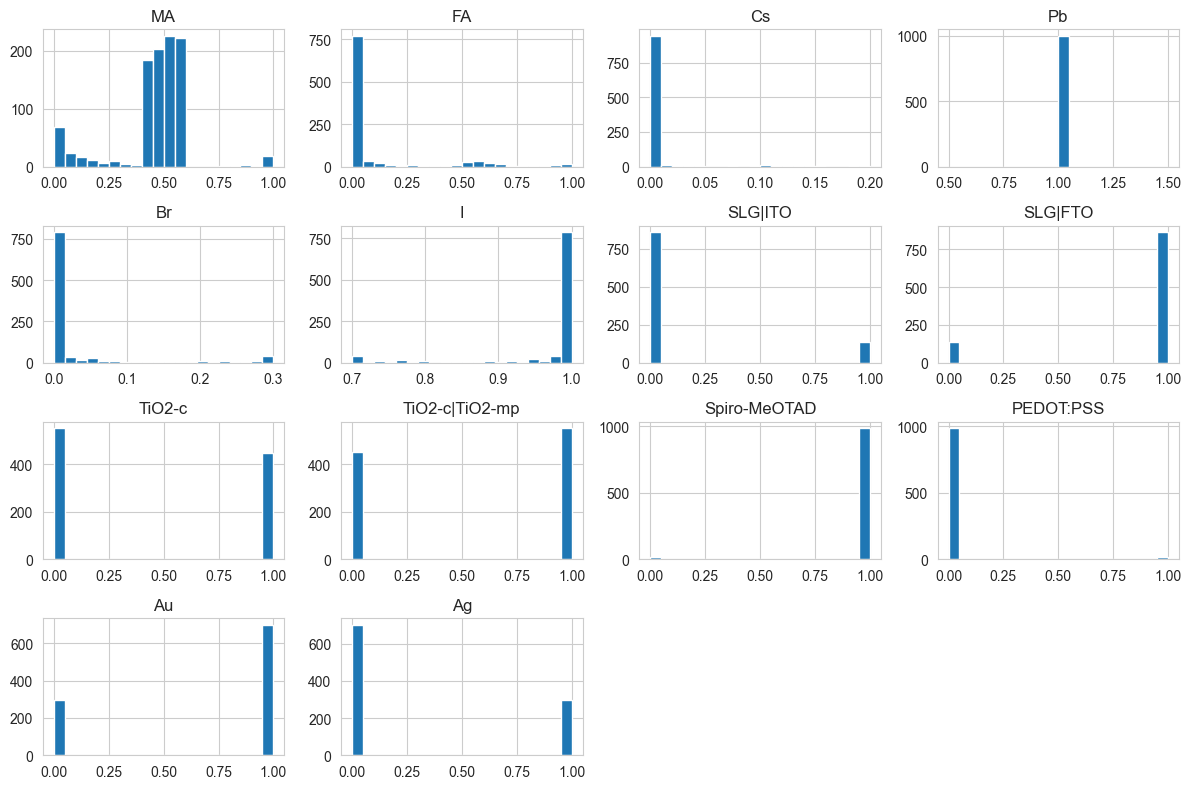

In [ ]:
import pandas as pd

# Convert decoded samples into a DataFrame
# call generated_perovskite_stacks.csv

df = pd.read_csv(r'C:\Users\c\OneDrive\Documents\PEROVSKITE PROJECT\PerovskiteML_project\Composition model\generated_perovskite_stacks.csv')

# Display the first few rows
print(df.head())

# # Save to CSV if needed
# df.to_csv("generated_stacks.csv", index=False)

import matplotlib.pyplot as plt

df.hist(figsize=(12, 8), bins=20)  # Adjust bins as needed
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.manifold import TSNE

# Reduce to 2D with t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
df_tsne = tsne.fit_transform(df)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(df_tsne[:, 0], df_tsne[:, 1], alpha=0.6)
plt.xlabel("t-SNE Dim 1")
plt.ylabel("t-SNE Dim 2")
plt.title("t-SNE Projection of Perovskite Stack Data")
plt.show()

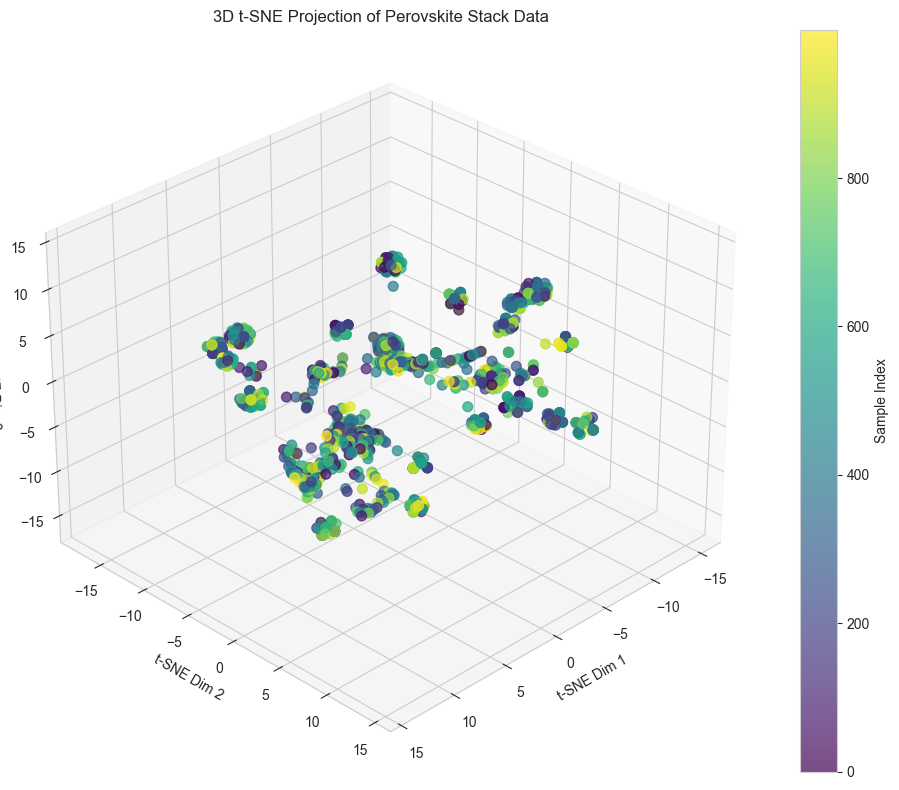

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Reduce to 3D with t-SNE (change n_components from 2 to 3)
tsne = TSNE(n_components=3, perplexity=30, random_state=42)
df_tsne = tsne.fit_transform(df)

# Create 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot with improved aesthetics
scatter = ax.scatter(
    df_tsne[:, 0], 
    df_tsne[:, 1], 
    df_tsne[:, 2],
    alpha=0.7,
    c=np.arange(len(df_tsne)),  # Color by index (or replace with categorical variable)
    cmap='viridis',
    s=50  # Marker size
)

# Add labels and title
ax.set_xlabel("t-SNE Dim 1")
ax.set_ylabel("t-SNE Dim 2")
ax.set_zlabel("t-SNE Dim 3")
ax.set_title("3D t-SNE Projection of Perovskite Stack Data")

# Add a color bar to show the mapping
plt.colorbar(scatter, ax=ax, label='Sample Index')

# Add grid for better depth perception
ax.grid(True)

# Adjust the viewing angle for better visualization
ax.view_init(elev=30, azim=45)

plt.tight_layout()
plt.show()

In [ ]:
csv_path = r"C:\Users\c\OneDrive\Documents\PEROVSKITE PROJECT\PerovskiteML_project\Regression model\cleaned_data_for_regression.csv"

# Load and preprocess data
data = load_data(csv_path, selected_columns)
dataset = TensorDataset(data)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Initialize model
input_dim = len(selected_columns)
vae = VAE(input_dim)

# Train model
trained_vae = train_vae(vae, dataloader, epochs=50, lr=0.001)

# Generate and decode new samples
new_samples = generate_samples(trained_vae, num_samples=1000)
decoded_samples = decode_generated_samples(new_samples, selected_columns)

print("\nGenerated Perovskite Cell Stacks:")
print(len(decoded_samples))
for i, sample in enumerate(decoded_samples, 1):
    print(f"\nStack {i}: {sample}")

torch.save(trained_vae.state_dict(), "vae_model.pth")
print("\nModel saved as 'vae_model.pth'.")

Epoch 1/50, Loss: 0.1141
Epoch 2/50, Loss: 0.0501
Epoch 3/50, Loss: 0.0340
Epoch 4/50, Loss: 0.0322
Epoch 5/50, Loss: 0.0310
Epoch 6/50, Loss: 0.0272
Epoch 7/50, Loss: 0.0236
Epoch 8/50, Loss: 0.0218
Epoch 9/50, Loss: 0.0198
Epoch 10/50, Loss: 0.0183
Epoch 11/50, Loss: 0.0172
Epoch 12/50, Loss: 0.0168
Epoch 13/50, Loss: 0.0164
Epoch 14/50, Loss: 0.0163
Epoch 15/50, Loss: 0.0160
Epoch 16/50, Loss: 0.0159
Epoch 17/50, Loss: 0.0157
Epoch 18/50, Loss: 0.0157
Epoch 19/50, Loss: 0.0157
Epoch 20/50, Loss: 0.0155
Epoch 21/50, Loss: 0.0154
Epoch 22/50, Loss: 0.0153
Epoch 23/50, Loss: 0.0153
Epoch 24/50, Loss: 0.0152
Epoch 25/50, Loss: 0.0151
Epoch 26/50, Loss: 0.0151
Epoch 27/50, Loss: 0.0150
Epoch 28/50, Loss: 0.0152
Epoch 29/50, Loss: 0.0150
Epoch 30/50, Loss: 0.0149
Epoch 31/50, Loss: 0.0150
Epoch 32/50, Loss: 0.0149
Epoch 33/50, Loss: 0.0147
Epoch 34/50, Loss: 0.0146
Epoch 35/50, Loss: 0.0148
Epoch 36/50, Loss: 0.0147
Epoch 37/50, Loss: 0.0148
Epoch 38/50, Loss: 0.0148
Epoch 39/50, Loss: 0.

In [ ]:
csv_path = r"C:\Users\c\OneDrive\Documents\PEROVSKITE PROJECT\PerovskiteML_project\Regression model\cleaned_data_for_regression.csv"

selected_columns = ['SLG|ITO', 'SLG|FTO', 'TiO2-c', 'TiO2-c|TiO2-mp', 'MA', 'FA', 'Cs', 'Pb', 'Br', 'I', 
                    'Spiro-MeOTAD', 'PEDOT:PSS', 'Au', 'Ag']

# Load and preprocess data
data = load_data(csv_path, selected_columns)
dataset = TensorDataset(data)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Initialize model
input_dim = len(selected_columns)
vae = VAE(input_dim)

# Train model
trained_vae = train_vae(vae, dataloader, epochs=50, lr=0.001)

# Generate and decode new samples
new_samples = generate_samples(trained_vae, num_samples=1000)
decoded_samples = decode_generated_samples(new_samples, selected_columns)

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

# Function to extract latent space representations
def get_latent_vectors(vae, dataloader, device="cpu"):
    vae.eval()
    latent_vectors = []
    with torch.no_grad():
        for batch in dataloader:
            batch = batch.to(device)
            z_mean, z_log_var = vae.encoder(batch)  # Assuming your encoder outputs mean and log variance
            z = z_mean  # Use mean representation for visualization
            latent_vectors.append(z.cpu().numpy())
    
    return np.vstack(latent_vectors)

# Assuming you have a DataLoader for your original dataset:
latent_vectors = get_latent_vectors(trained_vae, dataloader)  # Shape: (num_samples, latent_dim)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
latent_tsne = tsne.fit_transform(latent_vectors)

plt.figure(figsize=(6,6))
sns.scatterplot(x=latent_tsne[:, 0], y=latent_tsne[:, 1], alpha=0.7)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Projection of Latent Space")
plt.show()


Epoch 1/50, Loss: 0.1087
Epoch 2/50, Loss: 0.0391
Epoch 3/50, Loss: 0.0327
Epoch 4/50, Loss: 0.0312
Epoch 5/50, Loss: 0.0287
Epoch 6/50, Loss: 0.0247
Epoch 7/50, Loss: 0.0213
Epoch 8/50, Loss: 0.0196
Epoch 9/50, Loss: 0.0186
Epoch 10/50, Loss: 0.0180
Epoch 11/50, Loss: 0.0178
Epoch 12/50, Loss: 0.0172
Epoch 13/50, Loss: 0.0168
Epoch 14/50, Loss: 0.0167
Epoch 15/50, Loss: 0.0164
Epoch 16/50, Loss: 0.0164
Epoch 17/50, Loss: 0.0162
Epoch 18/50, Loss: 0.0160
Epoch 19/50, Loss: 0.0161
Epoch 20/50, Loss: 0.0161
Epoch 21/50, Loss: 0.0159
Epoch 22/50, Loss: 0.0157
Epoch 23/50, Loss: 0.0157
Epoch 24/50, Loss: 0.0157
Epoch 25/50, Loss: 0.0155
Epoch 26/50, Loss: 0.0156
Epoch 27/50, Loss: 0.0158
Epoch 28/50, Loss: 0.0154
Epoch 29/50, Loss: 0.0153
Epoch 30/50, Loss: 0.0154
Epoch 31/50, Loss: 0.0152
Epoch 32/50, Loss: 0.0151
Epoch 33/50, Loss: 0.0152
Epoch 34/50, Loss: 0.0151
Epoch 35/50, Loss: 0.0150
Epoch 36/50, Loss: 0.0148
Epoch 37/50, Loss: 0.0149
Epoch 38/50, Loss: 0.0148
Epoch 39/50, Loss: 0.

AttributeError: 'list' object has no attribute 'to'

In [ ]:
import joblib

df = pd.read_csv(r'C:\Users\c\OneDrive\Documents\PEROVSKITE PROJECT\PerovskiteML_project\Composition model\generated_perovskite_stacks.csv')

# Load trained models
bandgap_model = joblib.load("best_xgb_Perovskite_band_gap.1.pkl")
pce_model = joblib.load("best_xgb_JV_default_PCE.pkl")

# Define the expected feature columns (same as during training)
feature_columns = ['MA', 'FA', 'Cs', 'Pb', 'Br', 'I',
                   'SLG|ITO', 'SLG|FTO', 'TiO2-c', 'TiO2-c|TiO2-mp',
                   'Spiro-MeOTAD', 'PEDOT:PSS', 'Au', 'Ag']

# Select only necessary columns from the generated dataframe
X_generated = df[feature_columns]

# Predict band gap and PCE
df["Predicted_Band_Gap"] = bandgap_model.predict(X_generated)
df["Predicted_PCE"] = pce_model.predict(X_generated)

# Display results
print(df.head())

     MA    FA    Cs   Pb    Br     I  SLG|ITO  SLG|FTO  TiO2-c  \
0  0.48  0.00  0.00  1.0  0.00  1.00        0        1       0   
1  0.17  0.52  0.02  1.0  0.19  0.81        0        1       0   
2  0.00  0.01  0.15  1.0  0.30  0.77        1        0       1   
3  0.57  0.00  0.00  1.0  0.04  0.97        0        1       0   
4  0.59  0.00  0.00  1.0  0.00  1.00        1        0       1   

   TiO2-c|TiO2-mp  Spiro-MeOTAD  PEDOT:PSS  Au  Ag  Predicted_Band_Gap  \
0               1             1          0   1   0            1.577506   
1               1             1          0   1   0            1.611479   
2               0             1          0   0   1            1.698376   
3               1             1          0   1   0            1.587293   
4               0             1          0   0   1            1.573388   

   Predicted_PCE  
0      12.516311  
1      13.527050  
2       8.140197  
3      13.025076  
4      10.318747  


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better aesthetics
sns.set_style("whitegrid")

# Plot Band Gap Distribution
plt.figure(figsize=(6, 4))
sns.histplot(df["Predicted_Band_Gap"], bins=30, kde=True, color="blue")
plt.axvline(1.53, color='r', linestyle='--', label="Min. Suggested Band Gap (1.53 eV)")
plt.axvline(1.56, color='r', linestyle='--', label="Max. Suggested Band Gap (1.56 eV)")
plt.xlabel("Predicted Band Gap (eV)")
plt.ylabel("Count")
plt.title("Distribution of Predicted Band Gaps")
# Move legend outside
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)  
plt.show()

# Plot PCE Distribution
plt.figure(figsize=(6, 4))
sns.histplot(df["Predicted_PCE"], bins=30, kde=True, color="green")
plt.xlabel("Predicted PCE (%)")
plt.ylabel("Count")
plt.title("Distribution of Predicted Power Conversion Efficiency (PCE)")
plt.show()

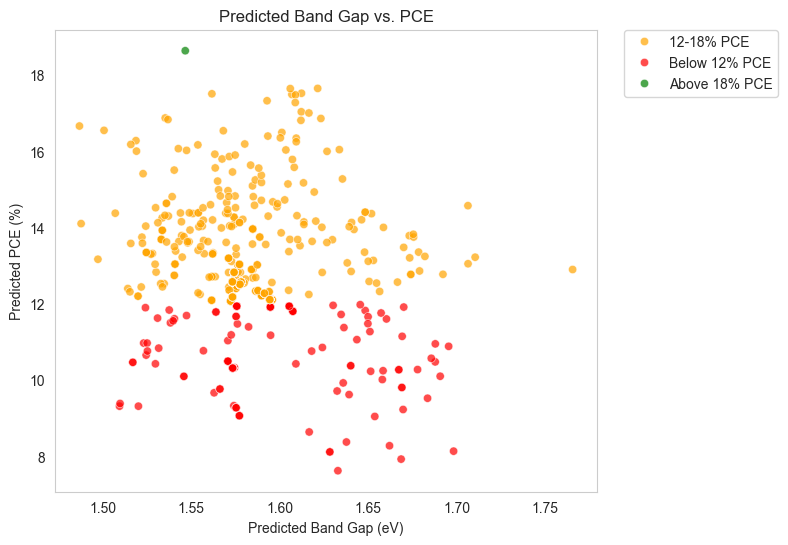

Row with highest Predicted PCE:
MA                             0.11
FA                             0.89
Cs                              0.0
Pb                              1.0
Br                             0.04
I                              0.95
SLG|ITO                           1
SLG|FTO                           0
TiO2-c                            1
TiO2-c|TiO2-mp                    0
Spiro-MeOTAD                      1
PEDOT:PSS                         0
Au                                1
Ag                                0
Predicted_Band_Gap          1.54656
Predicted_PCE              18.63999
PCE_Category          Above 18% PCE
Name: 321, dtype: object


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns



# Define color categories based on Predicted_PCE
def categorize_pce(pce):
    if pce < 12:
        return "Below 12% PCE"
    elif 12 <= pce <= 18:
        return "12-18% PCE"
    else:
        return "Above 18% PCE"

# Apply the function to create a new column
df["PCE_Category"] = df["Predicted_PCE"].apply(categorize_pce)

# Set a color palette
palette = {"Below 12% PCE": "red", "12-18% PCE": "orange", "Above 18% PCE": "green"}

# Plot
plt.figure(figsize=(7, 6))  # Increase figure width slightly for better spacing
sns.scatterplot(x=df["Predicted_Band_Gap"], 
                y=df["Predicted_PCE"], 
                hue=df["PCE_Category"],  # Color by PCE category
                palette=palette, 
                alpha=0.7)

# # Add vertical band gap limits
# plt.axvline(1.53, color='r', linestyle='--', label="Lower Band Gap Limit (1.53 eV)")
# plt.axvline(1.56, color='r', linestyle='--', label="Upper Band Gap Limit (1.56 eV)")

# Labels and title
plt.xlabel("Predicted Band Gap (eV)")
plt.ylabel("Predicted PCE (%)")
plt.title("Predicted Band Gap vs. PCE")

# Move legend outside
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)  

plt.grid(False)

# Show plot
plt.show()

# Identify the row with the highest Predicted_PCE
max_pce_row = df.loc[df["Predicted_PCE"].idxmax()]

# Print the row
print("Row with highest Predicted PCE:")
print(max_pce_row)


In [ ]:
top_pce_stacks = df.sort_values("Predicted_PCE", ascending=False).head(10)
print("🔹 Top 10 Stacks with Highest PCE:")
print(top_pce_stacks)


🔹 Top 10 Stacks with Highest PCE:
       MA    FA    Cs   Pb    Br     I  SLG|ITO  SLG|FTO  TiO2-c  \
481  0.08  0.92  0.00  1.0  0.06  0.92        0        1       1   
736  0.06  0.87  0.02  1.0  0.07  0.93        0        1       0   
214  0.01  0.90  0.05  1.0  0.01  0.99        0        1       1   
217  0.05  0.89  0.03  1.0  0.07  0.92        0        1       0   
191  0.08  0.92  0.00  1.0  0.21  0.79        0        1       1   
879  0.09  0.79  0.02  1.0  0.08  0.92        0        1       0   
294  0.03  0.97  0.00  1.0  0.04  0.95        0        1       1   
513  0.12  0.88  0.00  1.0  0.18  0.81        0        1       1   
10   0.01  0.90  0.02  1.0  0.04  0.96        0        1       0   
642  0.01  0.90  0.02  1.0  0.04  0.96        0        1       0   

     TiO2-c|TiO2-mp  Spiro-MeOTAD  PEDOT:PSS  Au  Ag  Predicted_Band_Gap  \
481               0             1          0   1   0            1.590263   
736               1             1          0   1   0            1

Check if they exist in the dataframe (whether they're novel or not):

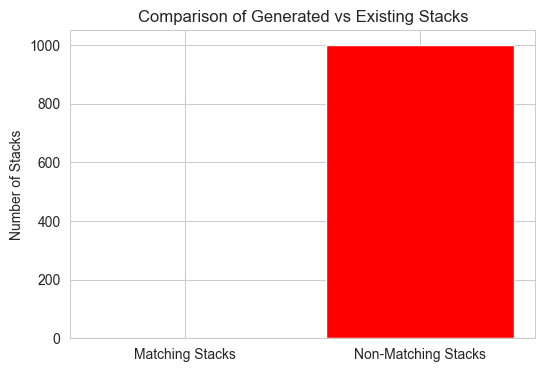

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'original_df' is your original dataset
# And 'generated_df' is your newly generated dataset

original_df = pd.read_csv(r'C:\Users\c\OneDrive\Documents\PEROVSKITE PROJECT\PerovskiteML_project\Regression model\cleaned_data_for_regression.csv')

# Step 1: Ensure both dataframes have the same order of columns
common_columns = list(set(original_df.columns) & set(df.columns))  # Find matching columns
original_df_sorted = original_df[common_columns].copy()
generated_df_sorted = df[common_columns].copy()

# Step 2: Convert to tuples for easy row-wise comparison
original_tuples = set([tuple(row) for row in original_df_sorted.to_numpy()])
generated_tuples = [tuple(row) for row in generated_df_sorted.to_numpy()]

# Step 3: Count matches
num_matching = sum(1 for row in generated_tuples if row in original_tuples)
num_non_matching = len(generated_df_sorted) - num_matching

# Step 4: Plot the results
plt.figure(figsize=(6, 4))
plt.bar(["Matching Stacks", "Non-Matching Stacks"], [num_matching, num_non_matching], color=['green', 'red'])
plt.ylabel("Number of Stacks")
plt.title("Comparison of Generated vs Existing Stacks")
plt.show()